# MiniProject #01: Cobblestone Gifts E-Commerce Data

by Patrick Donnelly & Burke Havranek

EECE 6544: Introduction to Machine Learning and Pattern Recognition

Northeastern University College of Engineering

Summer 2026, Session B

## Scenario

You have just joined the analytics team at **Cobblestone Gifts**, a UK-based online retailer that sells all-occasion
novelty gifts to both wholesale buyers and individual shoppers. The company has never run a formal sales review.
With the financial year closing, the Head of Commercial wants a clear picture of what sold, to whom, and where
but the only thing the IT team can hand you is a single raw export pulled straight from the order system: roughly
half a million transaction lines from December 2010 to December 2011.

The export has never been touched. It mixes completed sales with **cancelled orders and returns**, is missing a
customer ID on a large share of rows, contains **blank product descriptions** and **duplicate lines**, and is peppered
with non-product entries such as postage, bank charges, and manual adjustments. Prices and quantities include
impossible values. In short: **no number in this file can be trusted yet**.

Your job is to clean it. You will profile the data, make and document defensible cleaning decisions, build a tidy
*completed-sales* dataset, and then use it to answer a set of real business questions. The Head of Commercial
will read your findings so every claim must rest on data you can stand behind.

## Part 1: Clean the Data

### Phase A: Load & Profile

#### #3.2: Getting Information

In [424]:
#!/bin/python3
# --Beginning of Code--
import sys, subprocess
def pipq(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", *pkgs])

pipq("scikit-learn", "pandas", "numpy", "matplotlib", "seaborn", "pandas", "kagglehub", "caseutil")

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 80)
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import caseutil

path = kagglehub.dataset_download("carrie1/ecommerce-data")
csv_file = os.path.join(path, "data.csv")
df = pd.read_csv(csv_file, encoding='ISO-8859-1')
df.to_csv('raw.csv', index=False)

In [425]:
print(df.shape) # Note the total rows
N_ROW, _ = df.shape

(541909, 8)


In [426]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [427]:
df.info() # Note the populated rows

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [428]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


From the above, we find 541909 total entries in the database, of which six field (InvoiceNo, StockCode, Quantity, InvoiceDate, UnitPrice, Country) are fully-populated with non-null data. Of the remaining two columns, `Description` is missing 1454 entries (~0.268%), whereas `CustomerID` is missing 135080 entries (~24.9%).

#### #3.9 Unique Values

In [429]:
# Naive count of all unique elements in each column
df[["Country", "StockCode", "Description"]].nunique()

Country          38
StockCode      4070
Description    4223
dtype: int64

In [430]:
# Enumeration of each column with and without consideration of null columns
df["Country"].value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [431]:
df["Country"].value_counts(dropna=False)

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [432]:
df["StockCode"].value_counts()

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
          ... 
23609        1
85179a       1
23617        1
90214U       1
47591b       1
Name: count, Length: 4070, dtype: int64

In [433]:
df["StockCode"].value_counts(dropna=False)

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
          ... 
23609        1
85179a       1
23617        1
90214U       1
47591b       1
Name: count, Length: 4070, dtype: int64

In [434]:
df["Description"].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
                                      ... 
LETTER "U" BLING KEY RING                1
wet                                      1
wet boxes                                1
????damages????                          1
lost                                     1
Name: count, Length: 4223, dtype: int64

In [435]:
df["Description"].value_counts(dropna=False)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
                                      ... 
LETTER "U" BLING KEY RING                1
wet                                      1
wet boxes                                1
????damages????                          1
lost                                     1
Name: count, Length: 4224, dtype: int64

In [436]:
# Isolate non product codes
NON_PRODUCT = ["POST", "DOT", "M", "BANK CHARGES", "AMAZONFEE", "D"]
non_product = df[df["StockCode"].isin(NON_PRODUCT)]


In [437]:
non_product["StockCode"].value_counts()

StockCode
POST            1256
DOT              710
M                571
D                 77
BANK CHARGES      37
AMAZONFEE         34
Name: count, dtype: int64

#### #3.8: min/max/sum/mean/count

In [438]:
# Summarize quantity and unit price data (including returns)
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [439]:
# Identify returns
returns = df[df["Quantity"] < 0]
returns

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [440]:
# Identify invalid prices
invalid_prices = df[df["UnitPrice"] < 0]
invalid_prices

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


#### # 3.1 Creating a DataFrame

In [441]:
# Dictionary for right now to consolidate some regions
# Follows format following later replacement of EIRE, RSA, USA, Unspecified
COUNTRY_TO_REGION = {
    # UK/Ireland
    "United Kingdom": "UK&IE",
    "Ireland": "UK&IE",
    "Channel Islands": "UK&IE",

    # Mainland Europe (core)
    "Germany": "Continental Europe",
    "France": "Continental Europe",
    "Spain": "Continental Europe",
    "Netherlands": "Continental Europe",
    "Belgium": "Continental Europe",
    "Switzerland": "Continental Europe",
    "Portugal": "Continental Europe",
    "Italy": "Continental Europe",
    "Austria": "Continental Europe",
    "Denmark": "Continental Europe",
    "Norway": "Continental Europe",
    "Sweden": "Continental Europe",
    "Finland": "Continental Europe",
    "Iceland": "Continental Europe",
    "Cyprus": "Continental Europe",
    "Greece": "Continental Europe",
    "Malta": "Continental Europe",
    "Lithuania": "Continental Europe",
    "Poland": "Continental Europe",
    "Czech Republic": "Continental Europe",
    "European Community": "Continental Europe",

    # Middle East
    "Israel": "Middle East",
    "Lebanon": "Middle East",
    "United Arab Emirates": "Middle East",
    "Bahrain": "Middle East",
    "Saudi Arabia": "Middle East",

    # Africa
    "South Africa": "Africa",

    # Americas
    "United States": "Americas",
    "Canada": "Americas",
    "Brazil": "Americas",

    # Oceania
    "Australia": "Oceania",
    "Japan": "Oceania",
    "Hong Kong": "Oceania",
    "Singapore": "Oceania",

    # Unknown
    "": ""
}

### Phase B: Select & filter

#### #3.3: Slicing

#### #3.4: Conditional Selection

#### #3.5: Sorting Values

### Phase C: Clean & Fix

#### #3.6: Replacing Values

In [442]:
# Lengthen initialisms, make Unspecified nations null
MAP = {"EIRE": "Ireland", "RSA": "South Africa", "USA": "United States", "Unspecified": ""}
df["Country"] = df["Country"].map(lambda x: MAP[x] if x in MAP else x)
df["Country"].value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8557
Ireland                   8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
                           446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
United States              291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
South Africa                58


#### #3.7: Renaming Columns

In [443]:
# Use standard library to convert each column to snake_case
MAP = {x: caseutil.to_snake(x) for x in df.columns}
df.rename(columns=MAP, inplace=True)
df

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


#### #3.10: Handling Missing Values

In [444]:
df[df["description"].isnull()]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom


In [445]:
# Eliminate items lacking a description
df["description"].dropna(inplace=True)
df = df[~df["description"].isnull()]

In [446]:
df[df["customer_id"].isnull()]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


In [447]:
# Keep unknown CustomerID numbers
df["customer_id"].fillna(0, inplace=True)
df

/tmp/ipykernel_32376/2541043949.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["customer_id"].fillna(0, inplace=True)


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


Whereas relatively few entries (~0.268%) lack a description, nearly a quarter (~24.9%) lack a customer ID. Given the marginal number of entries lacking a description, the significance of product descriptions in noting consumer trends, and the fact that a lack of description appears to correlate with missing customer IDs and unit prices, these data should be excluded, and are able to be done so with minimal effect on the rest of the set. 

By contrast, the number of missing customer IDs is much too significant to exclude, and do not appear to correlate with any other missing data. Despite the fact that these entries are lacking information regarding specific customers, they still provide valuable data regarding consumer trends by both country and description.

#### #3.11: Deleting a Column

In [448]:
# Drop stock_code, as it is shadowed by description
df = df.drop(columns="stock_code")
df

,invoice_no,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


The `stock_code` column is redundant, carrying similar information to `description` and `quantity`, both of which are more useful columns to sort the data. Descriptions give a meaningful explanation of what was sold, or what transpired, and the quantity magnitude indicates returns, which renders the stock code redundant.

#### #3.12: Deleting a Row

In [449]:
# Delete cancellations, non-product lines, and impossible prices/quantities
df = df[df["quantity"] > 0] # Remove cancellations
df = df[~df["description"].isin(NON_PRODUCT)] # Remove non-products
df = df[df["unit_price"] > 0] # Remove impossible prices/quantities
df

,invoice_no,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


#### #3.13 Dropping Duplicates

In [450]:
print(f"Duplicate rows detected: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
df

Duplicate rows detected: 5295


,invoice_no,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


### Phase D: Engineer & Summarize

#### #3.18: Applying a Function

#### #3.17: Looping over a Column

#### #3.14: Grouping by Values

#### #3.16: Aggregating

#### #3.19: Applying to Groups

#### #3.15: Grouping by Time

### Phase E: Combine

#### #3.20: Concatenating

In [451]:
# Change date format into ISO sortable format
df["invoice_date"] = pd.to_datetime(df["invoice_date"], format="%m/%d/%Y %H:%M")
df.sort_values("invoice_date")

,invoice_no,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
541896,581587,PLASTERS IN TIN STRONGMAN,12,2011-12-09 12:50:00,1.65,12680.0,France
541895,581587,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,12680.0,France
541894,581587,CIRCUS PARADE LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France
541900,581587,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France


In [452]:
# Take rough midpoint of year and split table
split_date = '2011-06-15 00:00:00' # June 15th is the approximate midpoint of data range
df1 = df[df["invoice_date"] < split_date]
df1


,invoice_no,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
227019,556813,NATURAL SLATE CHALKBOARD LARGE,1,2011-06-14 17:28:00,9.96,NaN,United Kingdom
227020,556813,NATURAL SLATE HEART CHALKBOARD,1,2011-06-14 17:28:00,5.79,NaN,United Kingdom
227021,556813,MISTLETOE HEART WREATH CREAM,1,2011-06-14 17:28:00,4.15,NaN,United Kingdom
227022,556813,REGENCY TEA PLATE PINK,10,2011-06-14 17:28:00,1.65,NaN,United Kingdom


In [453]:
df2 = df[df["invoice_date"] > split_date]
df2

,invoice_no,description,quantity,invoice_date,unit_price,customer_id,country
227025,556814,LARGE ANTIQUE WHITE PHOTO FRAME,2,2011-06-15 08:34:00,7.90,14852.0,United Kingdom
227026,556814,SINGLE WIRE HOOK IVORY HEART,12,2011-06-15 08:34:00,1.45,14852.0,United Kingdom
227027,556814,TRIPLE WIRE HOOK IVORY HEART,4,2011-06-15 08:34:00,4.15,14852.0,United Kingdom
227028,556814,SMALL IVORY HEART WALL ORGANISER,3,2011-06-15 08:34:00,5.75,14852.0,United Kingdom
227029,556814,LARGE IVORY HEART WALL ORGANISER,2,2011-06-15 08:34:00,8.25,14852.0,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [454]:
# Recombine
df_cat = pd.concat([df1, df2])
df_cat

,invoice_no,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [455]:
# Verify recombination
assert df.equals(df_cat)

#### #3.21: Merging

In [456]:
df_regions = pd.DataFrame({"country": list(COUNTRY_TO_REGION.keys()), "region": list(COUNTRY_TO_REGION.values())})
df_left = df.merge(df_regions, how="left")
df_left

,invoice_no,description,quantity,invoice_date,unit_price,customer_id,country,region
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,UK&IE
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK&IE
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,UK&IE
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK&IE
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK&IE
...,...,...,...,...,...,...,...,...
524804,581587,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,Continental Europe
524805,581587,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,Continental Europe
524806,581587,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,Continental Europe
524807,581587,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,Continental Europe


In [457]:
df_inner = df.merge(df_regions, how="inner")
df_inner

,invoice_no,description,quantity,invoice_date,unit_price,customer_id,country,region
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,UK&IE
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK&IE
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,UK&IE
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK&IE
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK&IE
...,...,...,...,...,...,...,...,...
524804,581587,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,Continental Europe
524805,581587,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,Continental Europe
524806,581587,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,Continental Europe
524807,581587,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,Continental Europe


In [458]:
# Verify
assert df_left.equals(df_inner)
df = df_inner
df.to_csv('cleaned.csv', index=False)

In this particular instance, because all countries have been given their own mapping, both `df_left` and `df_inner` are identical. That is, the method of merge does not matter. Where not all countries are given a mapping, `how='left'` would maintain rows in the original database, converting all unmatched items to `NaN`, whereas `how='inner'` would merge rows only where the two overlap (that is, only where each country has an associated key).

## Part 2: Business Questions

### 1. Seasonality

We may calculate profits by multiplying the `quantity` column by the `unit_price` column, and sum each resulting transaction. Binning each by month in `invoice_date`, we find

In [459]:
df["month"] = df["invoice_date"].dt.to_period('M').dt.to_timestamp()
df["revenue"] = df["quantity"] * df["unit_price"]
df

,invoice_no,description,quantity,invoice_date,unit_price,customer_id,country,region,month,revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,UK&IE,2010-12-01,15.30
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK&IE,2010-12-01,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,UK&IE,2010-12-01,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK&IE,2010-12-01,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK&IE,2010-12-01,20.34
...,...,...,...,...,...,...,...,...,...,...
524804,581587,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,Continental Europe,2011-12-01,10.20
524805,581587,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,Continental Europe,2011-12-01,12.60
524806,581587,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,Continental Europe,2011-12-01,16.60
524807,581587,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,Continental Europe,2011-12-01,16.60


In [460]:
monthly = df.groupby("month")["revenue"].sum().sort_index()
monthly

month
2010-12-01     821380.660
2011-01-01     689753.650
2011-02-01     522540.600
2011-03-01     716187.840
2011-04-01     536958.571
2011-05-01     769269.890
2011-06-01     760538.380
2011-07-01     718064.991
2011-08-01     757831.380
2011-09-01    1056414.022
2011-10-01    1151256.310
2011-11-01    1503863.070
2011-12-01     637787.870
Name: revenue, dtype: float64

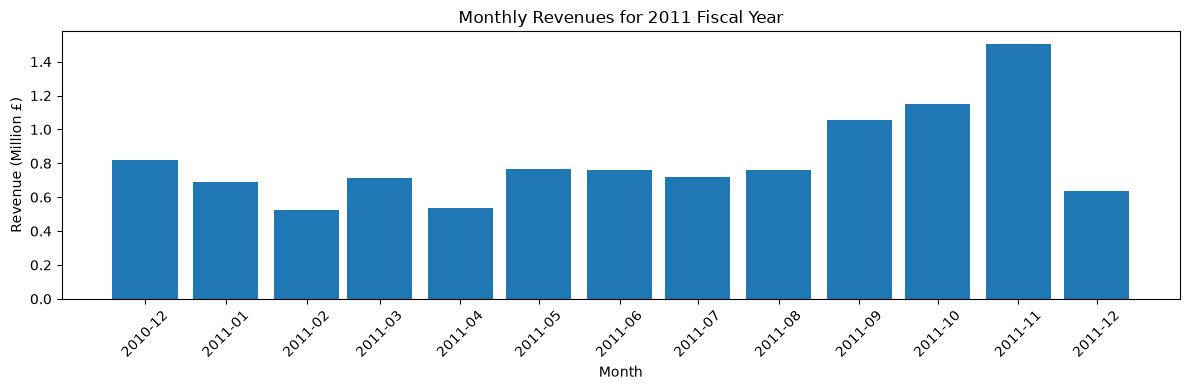

In [461]:
plt.figure(figsize=(12,4))
plt.bar(monthly.index, monthly.values / 1e6, width=25, align='center')
plt.xticks(monthly.index, [d.strftime('%Y-%m') for d in monthly.index], rotation=45)
plt.xlabel('Month')
plt.ylabel('Revenue (Million £)')
plt.title("Monthly Revenues for 2011 Fiscal Year")
plt.tight_layout()
plt.show()

Based on the above plot, revenues appear steady throughout much of the beginning of the year before quickly ramping up toward the December holidays, increasing sharply month-over-month from September to November before rebounding sharply in December proper.

### 2. Best Sellers

We may determine best sellers, by both revenue and volume, by binning sales `description` against `revenue` and `quantity`, respectively. Doing so, we find

In [462]:
revenue = df.groupby("description")["revenue"].sum().sort_values(ascending=False)
revenue.head(10)

description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: revenue, dtype: float64

In [463]:
volume = df.groupby("description")["quantity"].sum().sort_values(ascending=False)
volume.head(10)

description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: quantity, dtype: int64

Some items like the `PAPER CRAFT , LITTLE BIRDIE` and `JUMBO BAG RED RETROSPOT` top the above best sellers lists in terms of both revenue and sales volume, implying moderate margins. Our highest-revenue items, i.e. `DOTCOM POSTAGE` and `REGENCY CAKESTAND 3 TIER` account for many fewer units, implying they are higher-margin items.

### 3. Markets

Looking at markets outside the UK, examining revenue and distinct customers, we find

In [464]:
revenue_country = df[df["country"] != "United Kingdom"].groupby("country")["revenue"].sum().sort_values(ascending=False)
revenue_country.head(10)


country
Netherlands    285446.34
Ireland        283140.52
Germany        228678.40
France         209625.37
Australia      138453.81
Spain           61558.56
Switzerland     57067.60
Belgium         41196.34
Sweden          38367.83
Japan           37416.37
Name: revenue, dtype: float64

In [465]:
revenue_region = df[df["country"] != "United Kingdom"].groupby("region")["revenue"].sum().sort_values(ascending=False)
revenue_region.head(10)

region
Continental Europe    1097385.53
UK&IE                  303581.06
Oceania                212632.47
Middle East             12615.63
Americas                 8390.37
                         4740.94
Africa                   1002.31
Name: revenue, dtype: float64

In [466]:
customers_country = df[df["country"] != "United Kingdom"].groupby("country")["customer_id"].size().sort_values(ascending=False)
customers_country.head(10)

country
Germany        9025
France         8392
Ireland        7879
Spain          2479
Netherlands    2359
Belgium        2031
Switzerland    1958
Portugal       1492
Australia      1181
Norway         1071
Name: customer_id, dtype: int64

In [467]:
customers_region = df[df["country"] != "United Kingdom"].groupby("region")["customer_id"].size().sort_values(ascending=False)
customers_region.head(10)

region
Continental Europe    32969
UK&IE                  8626
Oceania                2004
                        442
Middle East             431
Americas                362
Africa                   57
Name: customer_id, dtype: int64

All of our best performing markets are, unsurprisingly, in the UK&IE area as well as Continental Europe. Interestingly, a significant portion of revenues and customers are from the Oceania region, though the market is less saturated, perhaps providing opportunity for overseas expansion.

### 4. Customer Concentration

Looking at top customers by revenue, we find

In [468]:
customers = df[~df["customer_id"].isnull()].groupby("customer_id")["revenue"].sum().sort_values(ascending=False)
customers.head(10)

customer_id
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: revenue, dtype: float64

In [469]:
share = customers.iloc[:(len(customers)//100)].sum() / df["revenue"].sum()
print(f"Top 1% Share: {100*share:0.2f}%")

Top 1% Share: 26.59%


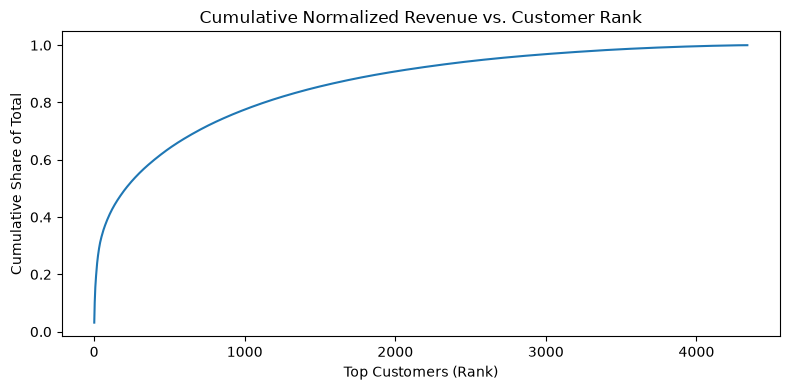

In [470]:
cum = np.cumsum(customers)
cum_share = cum / cum.max()

plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(customers)+1), cum_share)
plt.xlabel("Top Customers (Rank)")
plt.ylabel("Cumulative Share of Total")
plt.title("Cumulative Normalized Revenue vs. Customer Rank")
plt.tight_layout()
plt.show()

From this, we find that our top 1% of clients account for approximately one quarter of all revenue. This would indicate that our company services a significant number of wholesalers with large accounts, arguably dominating our revenues. The above plot emphasizes this dominance in showing that the top quarter of clients account for over 80% of all revenue, indicating significant disparity.

### 5. Order Value

Examining average invoice amounts, we find

In [471]:
RPI_UK = df[df["country"] == "United Kingdom"].groupby("invoice_no")["revenue"].sum().mean()
RPI_ELSEWHERE = df[df["country"] != "United Kingdom"].groupby("invoice_no")["revenue"].sum().mean()
print(f"Average Revenue Per Invoice\n\tUK: {RPI_UK:0.2f}\n\tElsewhere: {RPI_ELSEWHERE:0.2f}")

Average Revenue Per Invoice
	UK: 499.56
	Elsewhere: 845.10


From this, we find that foreign transactions yield, on average, nearly twice the revenue of domestic transactions, as quantified per invoice.

### 6. Returns & Cancellations

### 7. Data-Quality Memo